In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
# ============================================
# PHASE 2: VERIFY GPU + INSTALL LIBRARIES
# ============================================
import torch
print("PyTorch Version:", torch.__version__)
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

PyTorch Version: 2.10.0+cu128
GPU Available: True
GPU Name: Tesla T4


In [3]:
# ============================================
# STEP 2: IMPORT ALL LIBRARIES
# ============================================
import pandas as pd
import numpy as np
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# Disease labels
DISEASES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
    'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax', 'Consolidation',
    'Edema', 'Emphysema', 'Fibrosis', 'Pleural_Thickening', 'Hernia'
]
print("Number of disease classes:", len(DISEASES))

Using device: cuda
Number of disease classes: 14


In [5]:
# ============================================
# STEP 3: LOAD DATA + CREATE LABELS
# ============================================

# Load CSV
df = pd.read_csv('/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample_labels.csv')

# Clean age
df['Patient Age'] = df['Patient Age'].str.extract('(\d+)').astype(int)

# Create binary columns for each disease
for disease in DISEASES:
    df[disease] = df['Finding Labels'].apply(lambda x: 1 if disease in x else 0)

# Image folder path
IMAGE_DIR = '/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/'

# Keep only images that actually exist in the folder
existing_images = set(os.listdir(IMAGE_DIR))
df = df[df['Image Index'].isin(existing_images)].reset_index(drop=True)

print("Total images found:", len(df))
print("Sample labels:")
print(df[['Image Index', 'Finding Labels']].head())

Total images found: 5606
Sample labels:
        Image Index                                     Finding Labels
0  00000013_005.png  Emphysema|Infiltration|Pleural_Thickening|Pneu...
1  00000013_026.png                             Cardiomegaly|Emphysema
2  00000017_001.png                                         No Finding
3  00000030_001.png                                        Atelectasis
4  00000032_001.png                        Cardiomegaly|Edema|Effusion


In [6]:
# ============================================
# STEP 4: CREATE CUSTOM DATASET CLASS
# ============================================

class ChestXrayDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Load image
        img_path = os.path.join(self.image_dir, self.df.iloc[idx]['Image Index'])
        image = Image.open(img_path).convert('RGB')

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        # Get labels
        labels = torch.FloatTensor(self.df.iloc[idx][DISEASES].values.astype(float))

        return image, labels

# ============================================
# STEP 5: DEFINE TRANSFORMS
# ============================================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# ============================================
# STEP 6: SPLIT DATA
# ============================================

IMAGE_DIR = '/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/'

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

# Create datasets
train_dataset = ChestXrayDataset(train_df, IMAGE_DIR, train_transform)
val_dataset = ChestXrayDataset(val_df, IMAGE_DIR, val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train size: 4484
Val size: 1122
Train batches: 141
Val batches: 36


In [7]:
# ============================================
# STEP 7: BUILD DENSENET121 MODEL
# ============================================

class DenseNet121ChestXray(nn.Module):
    def __init__(self, num_classes=14):
        super(DenseNet121ChestXray, self).__init__()
        
        # Load pretrained DenseNet121
        self.densenet = models.densenet121(weights='IMAGENET1K_V1')
        
        # Get the number of features in the last layer
        num_features = self.densenet.classifier.in_features
        
        # Replace classifier with our 14-class head
        self.densenet.classifier = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
            nn.Sigmoid()  # Sigmoid for multi-label (not softmax)
        )
    
    def forward(self, x):
        return self.densenet(x)

# Initialize model
model = DenseNet121ChestXray(num_classes=14).to(device)

# Loss and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy for multi-label
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print("Model ready!")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 209MB/s]


Total Parameters: 7,485,838
Trainable Parameters: 7,485,838
Model ready!


In [8]:
# ============================================
# STEP 8: TRAINING LOOP
# ============================================

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    
    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if batch_idx % 20 == 0:
            print(f"  Batch {batch_idx}/{len(loader)} - Loss: {loss.item():.4f}")
    
    return running_loss / len(loader)


def val_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_outputs = []
    
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            all_labels.append(labels.cpu().numpy())
            all_outputs.append(outputs.cpu().numpy())
    
    all_labels = np.concatenate(all_labels, axis=0)
    all_outputs = np.concatenate(all_outputs, axis=0)
    
    # Calculate AUC per disease
    aucs = []
    for i, disease in enumerate(DISEASES):
        if len(np.unique(all_labels[:, i])) > 1:
            auc = roc_auc_score(all_labels[:, i], all_outputs[:, i])
            aucs.append(auc)
        else:
            aucs.append(0.0)
    
    mean_auc = np.mean([a for a in aucs if a > 0])
    return running_loss / len(loader), aucs, mean_auc


# ============================================
# STEP 9: RUN TRAINING (5 EPOCHS)
# ============================================

NUM_EPOCHS = 5
best_auc = 0.0
history = []

print("Starting training...")
print("=" * 50)

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 30)
    
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, aucs, mean_auc = val_epoch(model, val_loader, criterion, device)
    
    history.append({
        'epoch': epoch+1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'mean_auc': mean_auc
    })
    
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Mean AUC:   {mean_auc:.4f}")
    
    # Save best model
    if mean_auc > best_auc:
        best_auc = mean_auc
        torch.save(model.state_dict(), '/kaggle/working/best_model.pth')
        print(f"  ✓ Best model saved! AUC: {best_auc:.4f}")

print("\n" + "=" * 50)
print(f"Training Complete! Best AUC: {best_auc:.4f}")

Starting training...

Epoch 1/5
------------------------------
  Batch 0/141 - Loss: 0.7057
  Batch 20/141 - Loss: 0.2632
  Batch 40/141 - Loss: 0.1419
  Batch 60/141 - Loss: 0.1737
  Batch 80/141 - Loss: 0.2108
  Batch 100/141 - Loss: 0.2154
  Batch 120/141 - Loss: 0.1458
  Batch 140/141 - Loss: 0.1865

Epoch 1 Summary:
  Train Loss: 0.2199
  Val Loss:   0.1686
  Mean AUC:   0.6717
  ✓ Best model saved! AUC: 0.6717

Epoch 2/5
------------------------------
  Batch 0/141 - Loss: 0.1508
  Batch 20/141 - Loss: 0.1528
  Batch 40/141 - Loss: 0.1890
  Batch 60/141 - Loss: 0.2104
  Batch 80/141 - Loss: 0.1285
  Batch 100/141 - Loss: 0.1589
  Batch 120/141 - Loss: 0.1707
  Batch 140/141 - Loss: 0.4696

Epoch 2 Summary:
  Train Loss: 0.1691
  Val Loss:   0.1646
  Mean AUC:   0.6978
  ✓ Best model saved! AUC: 0.6978

Epoch 3/5
------------------------------
  Batch 0/141 - Loss: 0.1976
  Batch 20/141 - Loss: 0.1768
  Batch 40/141 - Loss: 0.1762
  Batch 60/141 - Loss: 0.1279
  Batch 80/141 - Los

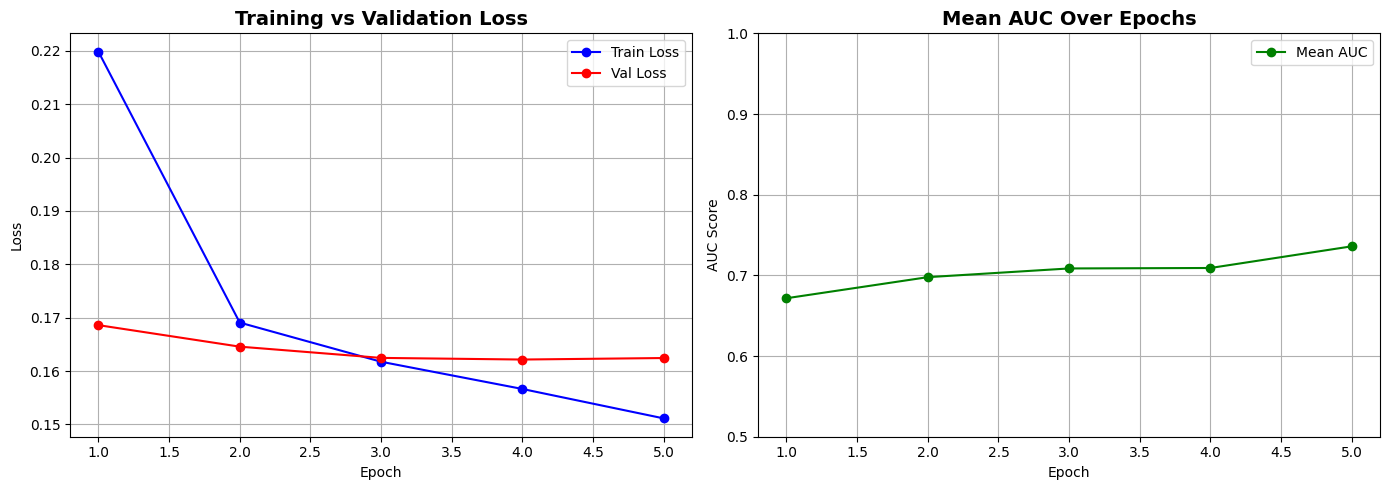

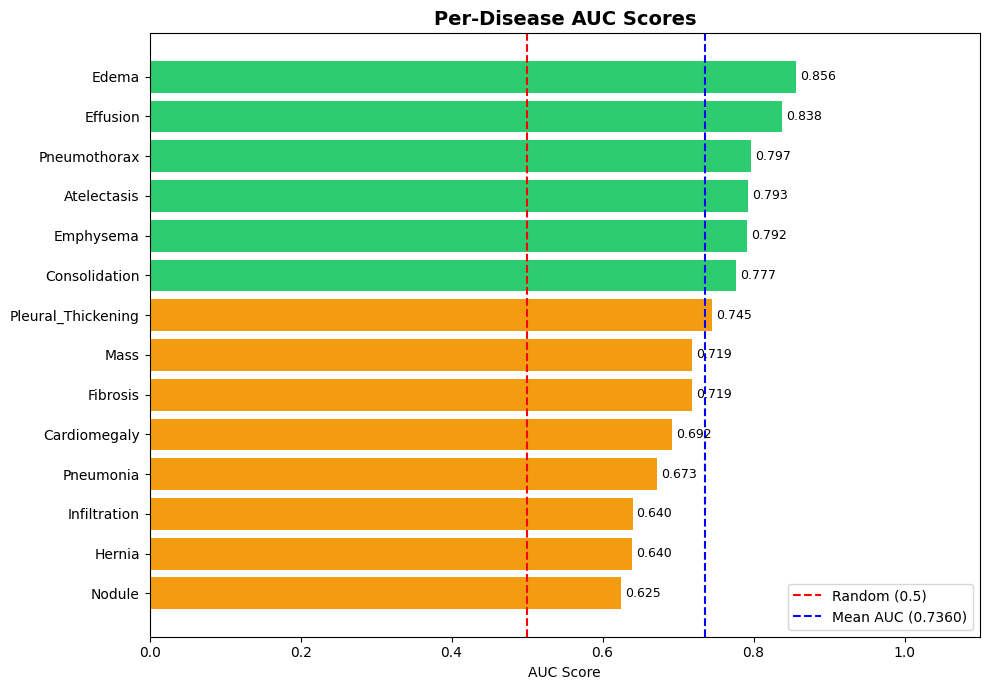

Plots saved!


In [9]:
# ============================================
# STEP 10: PLOT TRAINING CURVES + PER DISEASE AUC
# ============================================
import matplotlib.pyplot as plt

# --- Plot 1: Training Curves ---
epochs = [h['epoch'] for h in history]
train_losses = [h['train_loss'] for h in history]
val_losses = [h['val_loss'] for h in history]
mean_aucs = [h['mean_auc'] for h in history]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(epochs, train_losses, 'b-o', label='Train Loss')
axes[0].plot(epochs, val_losses, 'r-o', label='Val Loss')
axes[0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# AUC curve
axes[1].plot(epochs, mean_aucs, 'g-o', label='Mean AUC')
axes[1].set_title('Mean AUC Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC Score')
axes[1].set_ylim([0.5, 1.0])
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Plot 2: Per Disease AUC ---
_, final_aucs, _ = val_epoch(model, val_loader, criterion, device)

auc_df = pd.DataFrame({
    'Disease': DISEASES,
    'AUC': final_aucs
}).sort_values('AUC', ascending=True)

plt.figure(figsize=(10, 7))
colors = ['#e74c3c' if a < 0.6 else '#f39c12' if a < 0.75 else '#2ecc71' for a in auc_df['AUC']]
bars = plt.barh(auc_df['Disease'], auc_df['AUC'], color=colors)
plt.axvline(x=0.5, color='red', linestyle='--', label='Random (0.5)')
plt.axvline(x=0.7360, color='blue', linestyle='--', label=f'Mean AUC (0.7360)')
for bar, auc in zip(bars, auc_df['AUC']):
    plt.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'{auc:.3f}', va='center', fontsize=9)
plt.title('Per-Disease AUC Scores', fontsize=14, fontweight='bold')
plt.xlabel('AUC Score')
plt.xlim([0, 1.1])
plt.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/per_disease_auc.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plots saved!")

In [11]:
# ============================================
# IMPROVED TRAINING - FOCAL LOSS + SCHEDULER
# ============================================

# STEP 1: DEFINE FOCAL LOSS
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, outputs, targets):
        bce_loss = nn.BCELoss(reduction='none')(outputs, targets)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss.mean()

# STEP 2: LOAD YOUR SAVED MODEL
model.load_state_dict(torch.load('/kaggle/working/best_model.pth'))
print("Loaded saved model successfully!")

# STEP 3: FREEZE ALL LAYERS EXCEPT CLASSIFIER
for param in model.densenet.parameters():
    param.requires_grad = False
for param in model.densenet.classifier.parameters():
    param.requires_grad = True

# STEP 4: NEW OPTIMIZER + FOCAL LOSS + SCHEDULER
criterion = FocalLoss(gamma=2.0, alpha=0.25)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0003
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=2, factor=0.5
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")
print("Focal Loss + Scheduler ready!")

Loaded saved model successfully!
Trainable parameters: 531,982
Focal Loss + Scheduler ready!


In [12]:
# ============================================
# IMPROVED TRAINING LOOP - 10 EPOCHS
# ============================================

NUM_EPOCHS = 10
best_auc = 0.736  # Starting from your previous best
history2 = []

print("Phase 1: Training classifier head only (5 epochs)")
print("=" * 50)

for epoch in range(NUM_EPOCHS):
    
    # After 5 epochs, unfreeze all layers
    if epoch == 5:
        print("\n--- Unfreezing all layers ---")
        for param in model.densenet.parameters():
            param.requires_grad = True
        optimizer = optim.Adam(model.parameters(), lr=0.00003)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', patience=2, factor=0.5
        )
        print("Phase 2: Fine-tuning all layers (5 more epochs)")
        print("=" * 50)

    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, aucs, mean_auc = val_epoch(model, val_loader, criterion, device)

    # Scheduler step
    scheduler.step(mean_auc)

    history2.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'mean_auc': mean_auc
    })

    print(f"\nEpoch {epoch+1}/10")
    print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Mean AUC: {mean_auc:.4f}")

    # Save best model
    if mean_auc > best_auc:
        best_auc = mean_auc
        torch.save(model.state_dict(), '/kaggle/working/best_model_v2.pth')
        print(f"  ✓ New best model saved! AUC: {best_auc:.4f}")

print("\n" + "=" * 50)
print(f"Training Complete! Best AUC: {best_auc:.4f}")

Phase 1: Training classifier head only (5 epochs)
  Batch 0/141 - Loss: 0.0231
  Batch 20/141 - Loss: 0.0083
  Batch 40/141 - Loss: 0.0069
  Batch 60/141 - Loss: 0.0130
  Batch 80/141 - Loss: 0.0109
  Batch 100/141 - Loss: 0.0111
  Batch 120/141 - Loss: 0.0121
  Batch 140/141 - Loss: 0.0171

Epoch 1/10
  Train Loss: 0.0104 | Val Loss: 0.0113 | Mean AUC: 0.7589
  ✓ New best model saved! AUC: 0.7589
  Batch 0/141 - Loss: 0.0088
  Batch 20/141 - Loss: 0.0083
  Batch 40/141 - Loss: 0.0086
  Batch 60/141 - Loss: 0.0068
  Batch 80/141 - Loss: 0.0075
  Batch 100/141 - Loss: 0.0115
  Batch 120/141 - Loss: 0.0135
  Batch 140/141 - Loss: 0.0064

Epoch 2/10
  Train Loss: 0.0097 | Val Loss: 0.0116 | Mean AUC: 0.7537
  Batch 0/141 - Loss: 0.0082
  Batch 20/141 - Loss: 0.0069
  Batch 40/141 - Loss: 0.0090
  Batch 60/141 - Loss: 0.0105
  Batch 80/141 - Loss: 0.0096
  Batch 100/141 - Loss: 0.0083
  Batch 120/141 - Loss: 0.0087
  Batch 140/141 - Loss: 0.0148

Epoch 3/10
  Train Loss: 0.0097 | Val Loss:

In [13]:
# ============================================
# PHASE 3: FULL FINE-TUNING - 10 MORE EPOCHS
# ============================================

# Load best model so far
model.load_state_dict(torch.load('/kaggle/working/best_model_v2.pth'))
print("Loaded best model v2!")

# Unfreeze ALL layers
for param in model.densenet.parameters():
    param.requires_grad = True

# Lower learning rate for fine-tuning
optimizer = optim.Adam(model.parameters(), lr=0.00001)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=10, eta_min=1e-7
)

print("All layers unfrozen!")
print("Starting full fine-tuning for 10 more epochs...")
print("=" * 50)

best_auc = 0.7648
history3 = []

for epoch in range(10):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, aucs, mean_auc = val_epoch(model, val_loader, criterion, device)
    scheduler.step()

    history3.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'mean_auc': mean_auc
    })

    print(f"Epoch {epoch+1}/10 | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | AUC: {mean_auc:.4f}", end="")

    if mean_auc > best_auc:
        best_auc = mean_auc
        torch.save(model.state_dict(), '/kaggle/working/best_model_v3.pth')
        print(f" ✓ Best saved!")
    else:
        print()

print("\n" + "=" * 50)
print(f"Final Best AUC: {best_auc:.4f}")

Loaded best model v2!
All layers unfrozen!
Starting full fine-tuning for 10 more epochs...
  Batch 0/141 - Loss: 0.0098
  Batch 20/141 - Loss: 0.0061
  Batch 40/141 - Loss: 0.0102
  Batch 60/141 - Loss: 0.0087
  Batch 80/141 - Loss: 0.0079
  Batch 100/141 - Loss: 0.0090
  Batch 120/141 - Loss: 0.0096
  Batch 140/141 - Loss: 0.0111
Epoch 1/10 | Train Loss: 0.0090 | Val Loss: 0.0116 | AUC: 0.7616
  Batch 0/141 - Loss: 0.0090
  Batch 20/141 - Loss: 0.0090
  Batch 40/141 - Loss: 0.0082
  Batch 60/141 - Loss: 0.0051
  Batch 80/141 - Loss: 0.0109
  Batch 100/141 - Loss: 0.0085
  Batch 120/141 - Loss: 0.0099
  Batch 140/141 - Loss: 0.0104
Epoch 2/10 | Train Loss: 0.0088 | Val Loss: 0.0116 | AUC: 0.7613
  Batch 0/141 - Loss: 0.0051
  Batch 20/141 - Loss: 0.0080
  Batch 40/141 - Loss: 0.0083
  Batch 60/141 - Loss: 0.0121
  Batch 80/141 - Loss: 0.0096
  Batch 100/141 - Loss: 0.0087
  Batch 120/141 - Loss: 0.0076
  Batch 140/141 - Loss: 0.0143
Epoch 3/10 | Train Loss: 0.0086 | Val Loss: 0.0116 | 

In [14]:
# ============================================
# PHASE 3: GRAD-CAM INSTALLATION
# ============================================

!pip install grad-cam --quiet

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print("Grad-CAM installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 19.6 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 53.1 MB/s eta 0:00:0000:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 

In [15]:
# ============================================
# PHASE 3: GRAD-CAM VISUALIZATION
# ============================================

# Load best model
model.load_state_dict(torch.load('/kaggle/working/best_model_v2.pth'))
model.eval()

# Target layer for Grad-CAM (last conv layer of DenseNet121)
target_layer = [model.densenet.features.denseblock4.denselayer16.conv2]

# Initialize GradCAM
cam = GradCAM(model=model, target_layers=target_layer)

# ============================================
# FUNCTION: Generate Grad-CAM for one image
# ============================================

def generate_gradcam(image_path, disease_idx, disease_name):
    # Load original image
    original_img = Image.open(image_path).convert('RGB')
    original_img = original_img.resize((224, 224))
    original_np = np.array(original_img) / 255.0

    # Transform for model
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    input_tensor = transform(Image.open(image_path).convert('RGB')).unsqueeze(0).to(device)

    # Generate CAM
    targets = [ClassifierOutputTarget(disease_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    # Overlay heatmap on image
    visualization = show_cam_on_image(
        original_np.astype(np.float32),
        grayscale_cam,
        use_rgb=True
    )

    return original_np, grayscale_cam, visualization

print("Grad-CAM function ready!")
print("Generating visualizations...")

Grad-CAM function ready!
Generating visualizations...


✓ Generated Grad-CAM for Edema
✓ Generated Grad-CAM for Effusion
✓ Generated Grad-CAM for Pneumothorax
✓ Generated Grad-CAM for Atelectasis
✓ Generated Grad-CAM for Emphysema
✓ Generated Grad-CAM for Consolidation


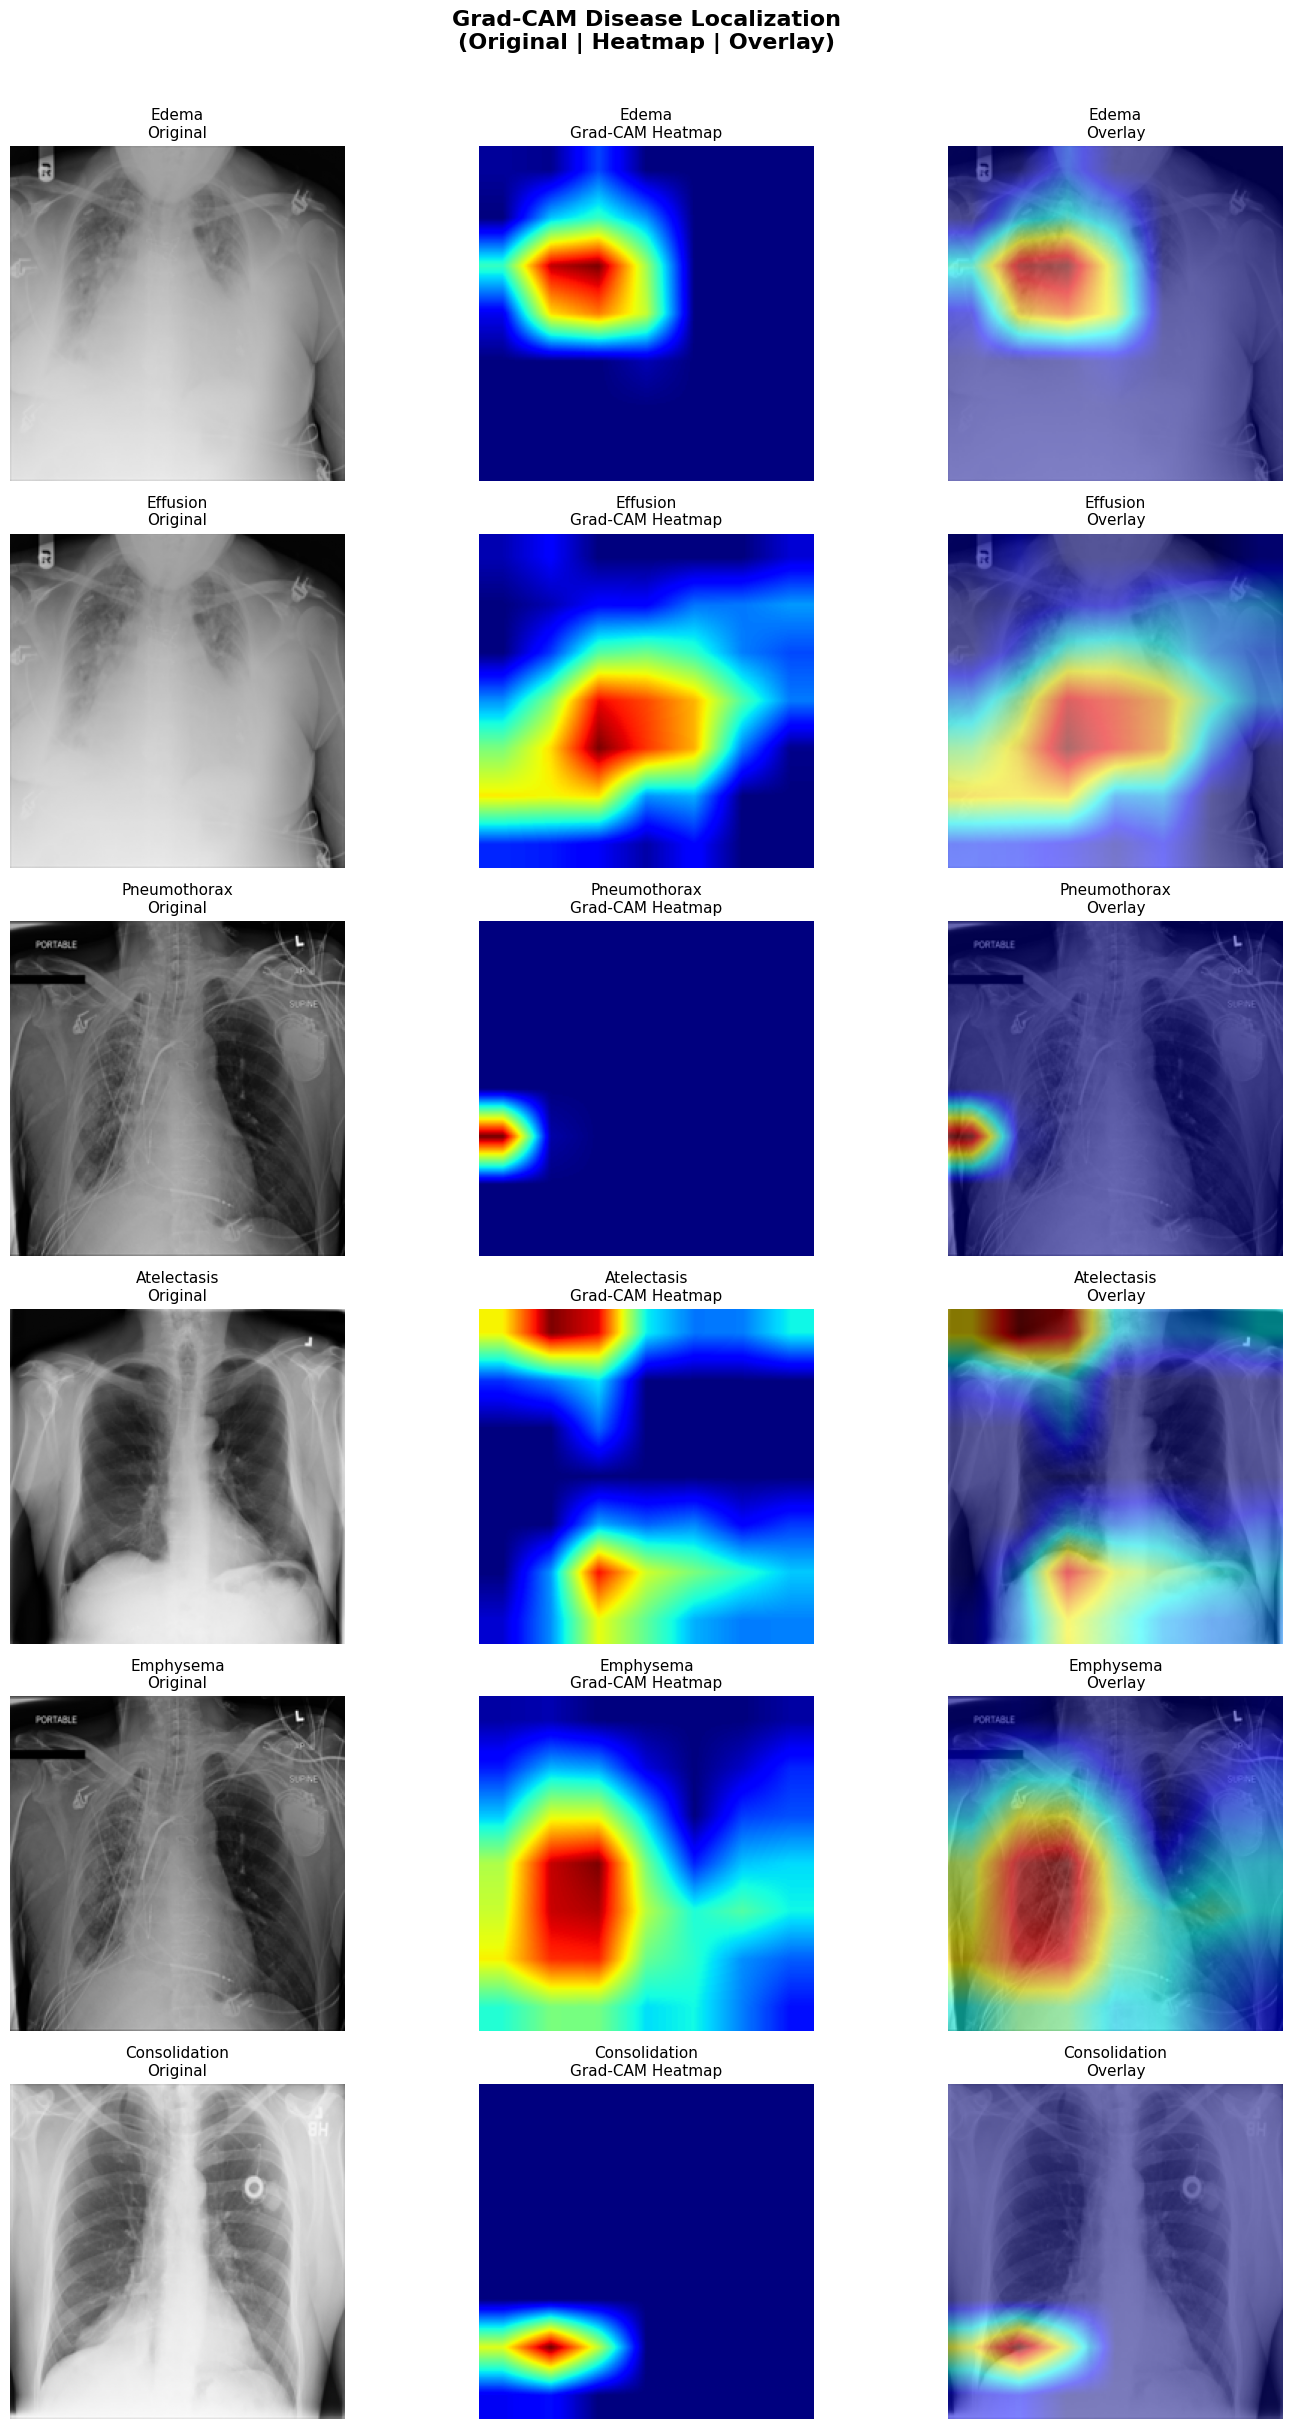


Grad-CAM visualizations saved!


In [16]:
# ============================================
# GENERATE GRAD-CAM FOR MULTIPLE DISEASES
# ============================================

IMAGE_DIR = '/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/'

# Pick diseases with highest AUC for best visualization
target_diseases = [
    ('Edema', 9),
    ('Effusion', 2),
    ('Pneumothorax', 7),
    ('Atelectasis', 0),
    ('Emphysema', 10),
    ('Consolidation', 8)
]

fig, axes = plt.subplots(len(target_diseases), 3, figsize=(15, 4*len(target_diseases)))
fig.suptitle('Grad-CAM Disease Localization\n(Original | Heatmap | Overlay)',
             fontsize=16, fontweight='bold', y=1.01)

for row, (disease_name, disease_idx) in enumerate(target_diseases):
    # Find an image that has this disease
    disease_images = df[df[disease_name] == 1]['Image Index'].values
    
    if len(disease_images) == 0:
        continue
    
    # Pick first available image
    img_found = False
    for img_name in disease_images:
        img_path = os.path.join(IMAGE_DIR, img_name)
        if os.path.exists(img_path):
            img_found = True
            break
    
    if not img_found:
        continue

    # Generate Grad-CAM
    original, heatmap, overlay = generate_gradcam(img_path, disease_idx, disease_name)

    # Plot original
    axes[row, 0].imshow(original)
    axes[row, 0].set_title(f'{disease_name}\nOriginal', fontsize=11)
    axes[row, 0].axis('off')

    # Plot heatmap
    axes[row, 1].imshow(heatmap, cmap='jet')
    axes[row, 1].set_title(f'{disease_name}\nGrad-CAM Heatmap', fontsize=11)
    axes[row, 1].axis('off')

    # Plot overlay
    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title(f'{disease_name}\nOverlay', fontsize=11)
    axes[row, 2].axis('off')

    print(f"✓ Generated Grad-CAM for {disease_name}")

plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nGrad-CAM visualizations saved!")

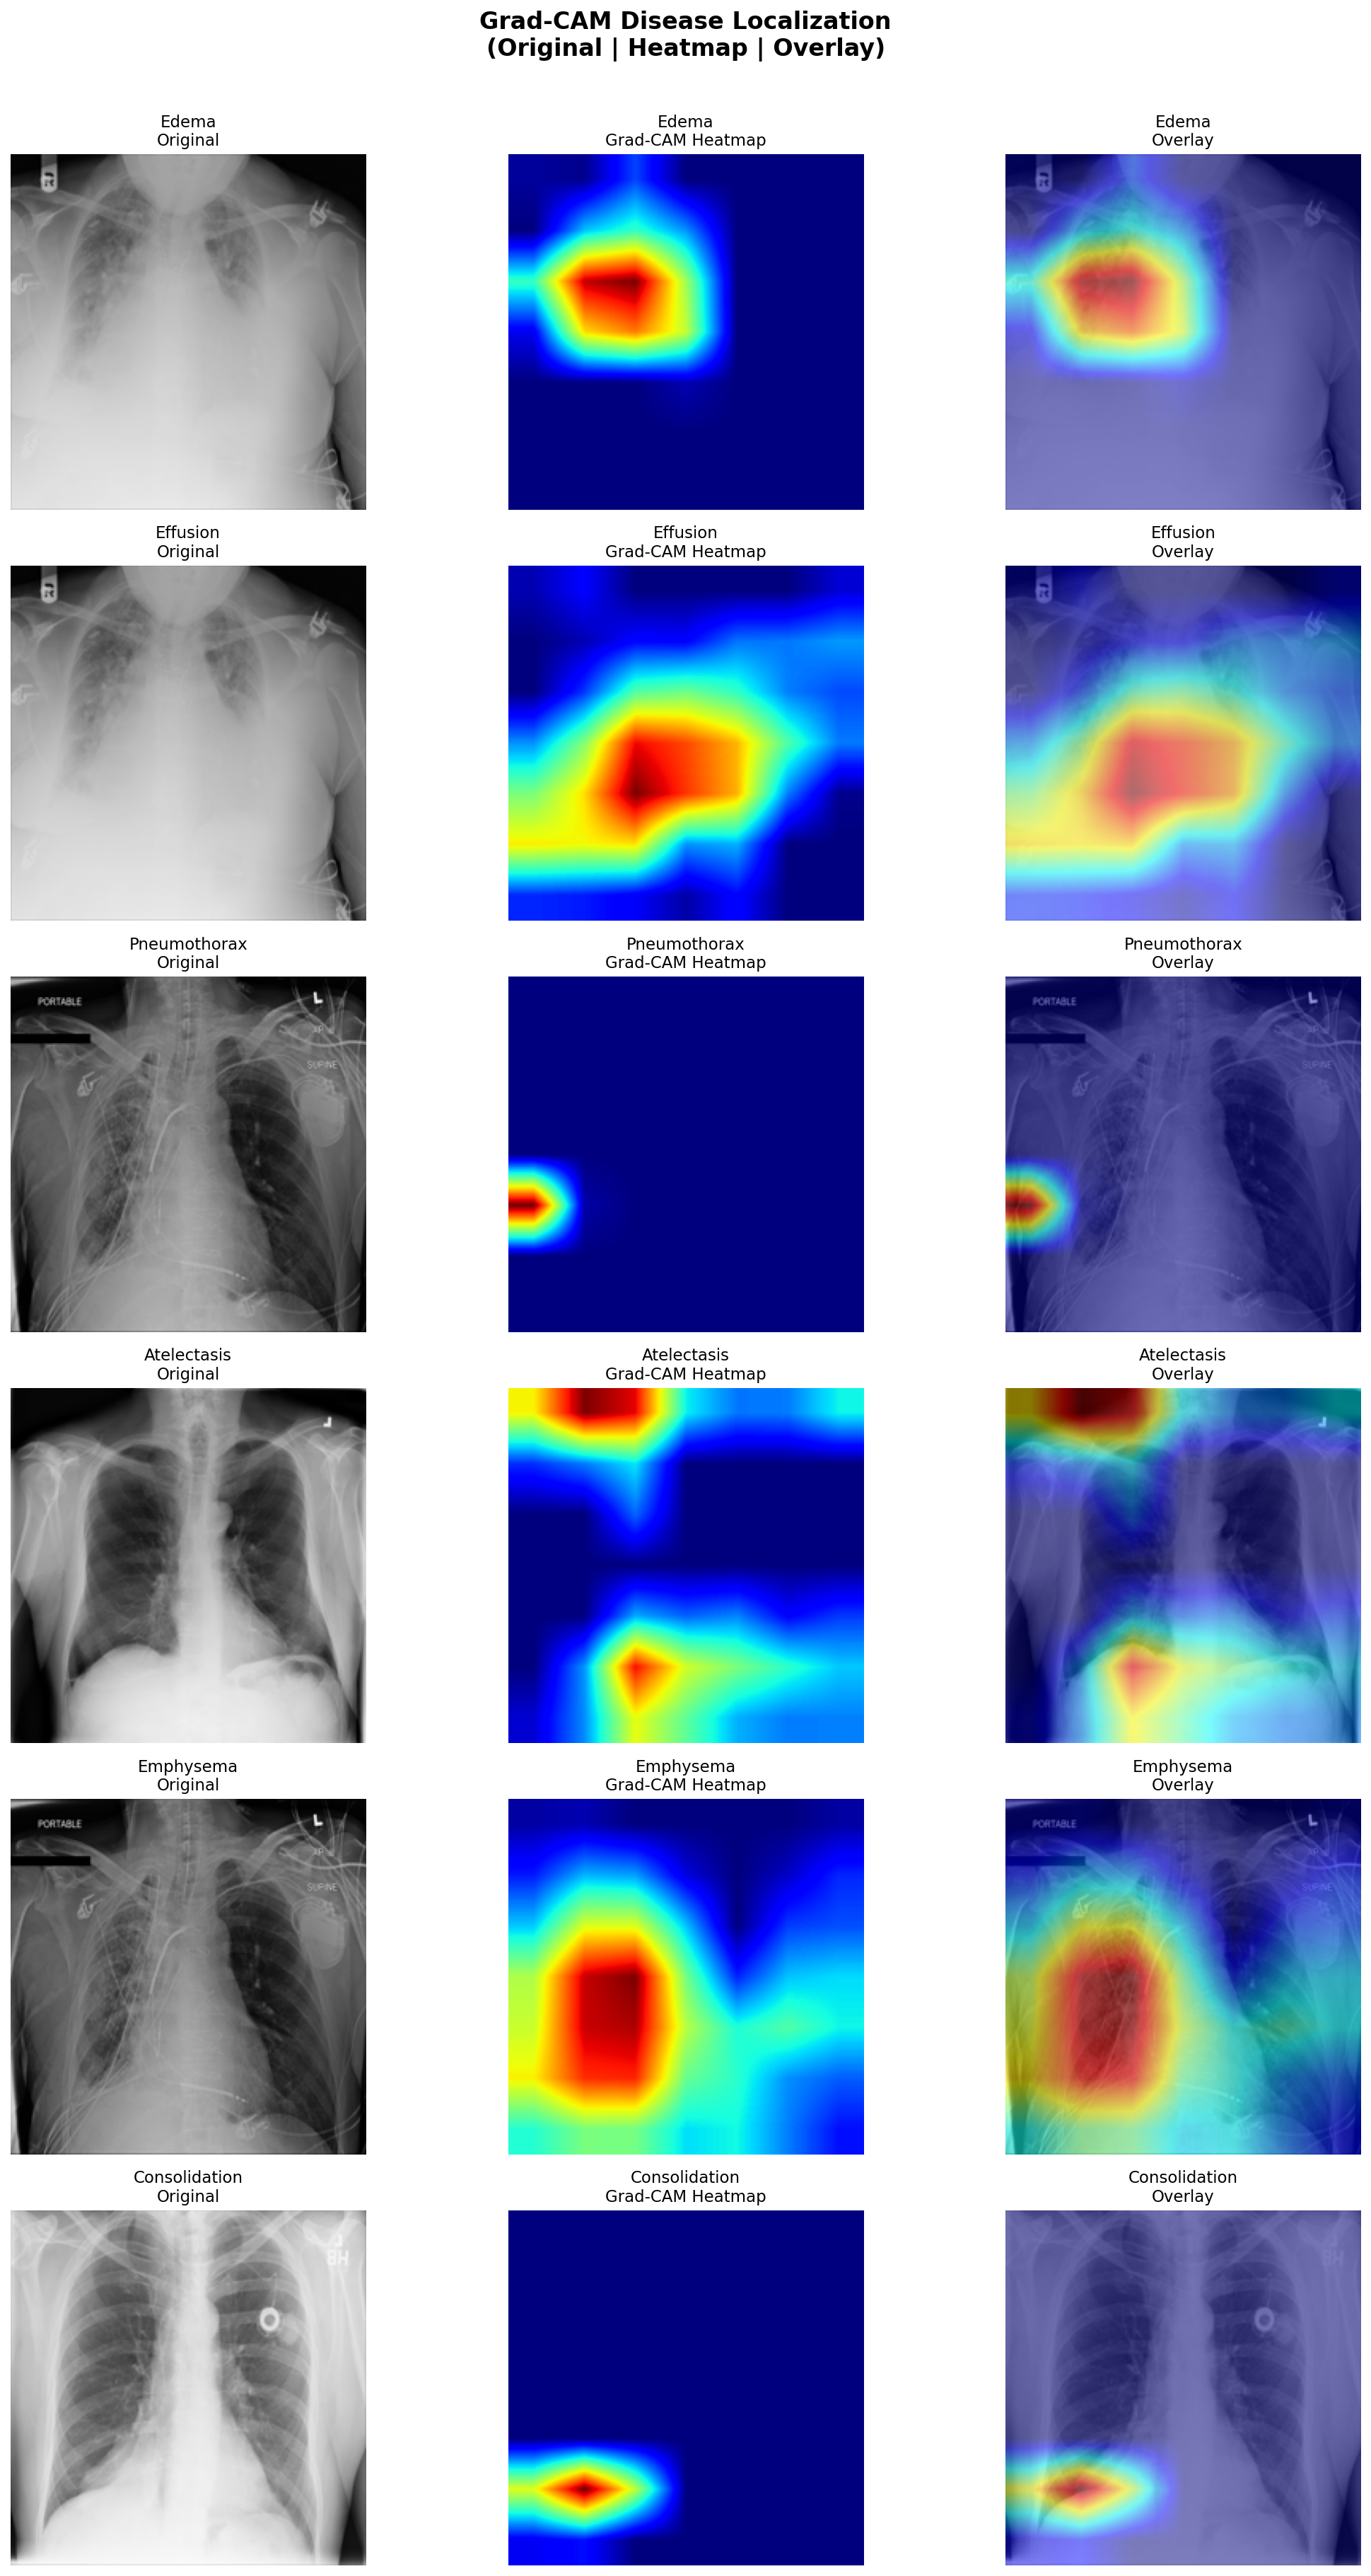

In [17]:
# ============================================
# DISPLAY GRAD-CAM RESULTS
# ============================================

from IPython.display import Image as IPImage
IPImage('/kaggle/working/gradcam_visualizations.png')

In [26]:
from huggingface_hub import InferenceClient

HF_TOKEN = "hf_token here"  # Paste your token here

client = InferenceClient(
    model="meta-llama/Meta-Llama-3-8B-Instruct",
    token=HF_TOKEN
)

# Test connection
test = client.chat_completion(
    messages=[{"role": "user", "content": "Say 'HuggingFace connected successfully' only."}],
    max_tokens=20
)
print(test.choices[0].message.content)

HuggingFace connected successfully


In [33]:
# ============================================
# PHASE 4: LLM CLINICAL REPORT GENERATOR (FIXED)
# ============================================

from datetime import datetime

def generate_llm_report(image_path, model, device, threshold=0.3):
    
    # Step 1: Get model predictions
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = outputs.squeeze().cpu().numpy()
    
    # Step 2: Get detected diseases
    detected = []
    for disease, prob in zip(DISEASES, probabilities):
        if prob >= threshold:
            detected.append((disease, float(prob)))
    detected = sorted(detected, key=lambda x: x[1], reverse=True)
    
    # Step 3: Grad-CAM
    target_layer = [model.densenet.features.denseblock4.denselayer16.conv2]
    grad_cam = GradCAM(model=model, target_layers=target_layer)
    top_idx = DISEASES.index(detected[0][0]) if detected else 0
    grayscale_cam = grad_cam(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(top_idx)]
    )[0]
    original_np = np.array(image.resize((224, 224))) / 255.0
    overlay = show_cam_on_image(
        original_np.astype(np.float32),
        grayscale_cam, use_rgb=True
    )
    
    # Step 4: Build LLM prompt
    if not detected:
        findings_text = "No significant findings detected. All probabilities below threshold."
    else:
        findings_text = "\n".join([
            f"- {disease}: {prob*100:.1f}% confidence"
            for disease, prob in detected
        ])
    
    prompt = f"""You are an expert radiologist AI assistant.
Based on the following chest X-ray AI analysis results, write a professional clinical radiology report.

DETECTED FINDINGS:
{findings_text}

Write a concise radiology report with these sections:
1. FINDINGS: Describe what was detected
2. IMPRESSION: Clinical interpretation and recommendation
3. FOLLOW-UP: What should be done next

Important rules:
- Do NOT include any patient information section
- Do NOT include placeholders like [Insert patient information]
- Start directly with FINDINGS section
- Keep it professional, concise, and clinically relevant
- End with: 'Note: This is an AI-assisted analysis. Clinical correlation required.'"""

    # Step 5: Generate LLM report
    response = client.chat_completion(
        messages=[{"role": "user", "content": prompt}],
        max_tokens=400
    )
    llm_report = response.choices[0].message.content

    # Step 6: Format final report
    now = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    final_report = f"""
╔══════════════════════════════════════════════════════════════╗
║           CHEST X-RAY AI ANALYSIS REPORT                    ║
╚══════════════════════════════════════════════════════════════╝
Date     : {now}
Model    : DenseNet121 (NIH ChestX-ray14) + Llama-3 8B
Image    : {os.path.basename(image_path)}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MODEL PREDICTIONS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━"""

    for disease, prob in zip(DISEASES, probabilities):
        bar = "█" * int(prob * 20)
        marker = " ◄" if prob >= threshold else ""
        final_report += f"\n  {disease:<22} {prob*100:5.1f}%  {bar}{marker}"

    final_report += f"""

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
AI RADIOLOGIST REPORT (Generated by Llama-3):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
{llm_report}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
⚠ DISCLAIMER: AI tool only. Not a substitute for professional
  medical diagnosis. Always consult a qualified radiologist.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""
    return final_report, overlay, detected, probabilities


print("Function defined successfully!")

Function defined successfully!


In [34]:
# ============================================
# RELAUNCH GRADIO WITH FIXED FUNCTION
# ============================================

def analyze_xray(image):
    try:
        temp_path = '/kaggle/working/temp_input.png'
        if isinstance(image, np.ndarray):
            Image.fromarray(image).save(temp_path)
        else:
            image.save(temp_path)

        report, overlay, detected, probs = generate_llm_report(
            temp_path, model, device, threshold=0.3
        )

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        original = Image.open(temp_path).convert('RGB')
        axes[0].imshow(original)
        axes[0].set_title('Original X-Ray', fontsize=13, fontweight='bold')
        axes[0].axis('off')
        axes[1].imshow(overlay)
        axes[1].set_title('Grad-CAM Heatmap\n(Model Focus Area)',
                          fontsize=13, fontweight='bold')
        axes[1].axis('off')

        if detected:
            top = detected[0]
            plt.suptitle(f'Top Finding: {top[0]} ({top[1]*100:.1f}%)',
                        fontsize=14, fontweight='bold', color='red')
        else:
            plt.suptitle('No Significant Findings',
                        fontsize=14, fontweight='bold', color='green')

        plt.tight_layout()
        fig_path = '/kaggle/working/gradio_output.png'
        plt.savefig(fig_path, dpi=120, bbox_inches='tight')
        plt.close()

        output_image = Image.open(fig_path)
        return output_image, report

    except Exception as e:
        return None, f"Error: {str(e)}"


with gr.Blocks(title="Chest X-Ray AI Analyzer") as demo:
    gr.Markdown("""
    # 🫁 Chest X-Ray AI Analyzer
    ### DenseNet121 + Grad-CAM + Llama-3 Clinical Report Generator
    Upload a chest X-ray image to get disease predictions, 
    heatmap visualization and AI clinical report.
    """)
    
    with gr.Row():
        with gr.Column():
            input_image = gr.Image(label="Upload Chest X-Ray", type="pil")
            analyze_btn = gr.Button("🔍 Analyze X-Ray", variant="primary", size="lg")
        with gr.Column():
            output_image = gr.Image(label="Analysis Results")
            output_report = gr.Textbox(label="Clinical Report", lines=30)
    
    analyze_btn.click(
        fn=analyze_xray,
        inputs=input_image,
        outputs=[output_image, output_report]
    )
    
    gr.Markdown("**⚠️ Disclaimer:** Research purposes only. Not a substitute for medical diagnosis.")

demo.launch(share=True, debug=False)

* Running on local URL:  http://127.0.0.1:7862
* Running on public URL: https://2822981d7d60eb1a58.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 420, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

In [35]:
import os
print("Files in output:")
for f in os.listdir('/kaggle/working'):
    size = os.path.getsize(f'/kaggle/working/{f}') / (1024*1024)
    print(f"  {f} — {size:.1f} MB")

Files in output:
  best_model_v2.pth — 29.1 MB
  report_Effusion.png — 0.4 MB
  .gradio — 0.0 MB
  report_Pneumothorax.png — 0.5 MB
  training_curves.png — 0.1 MB
  gradio_output.png — 0.3 MB
  report_Normal.png — 0.3 MB
  best_model.pth — 29.1 MB
  gradcam_visualizations.png — 2.1 MB
  per_disease_auc.png — 0.1 MB
  .virtual_documents — 0.0 MB
  temp_input.png — 0.4 MB


In [1]:
# Check the correct Gradio API endpoint
import requests

response = requests.post(
    "https://tirpal-chestxray-ai-analyzer.hf.space/run/predict",
    json={"data": ["test"]},
    headers={"Content-Type": "application/json"}
)
print("Status:", response.status_code)
print("Response:", response.text[:500])

Status: 405
Response: {"type":"error","error":{"message":"Method Not Allowed"}}


In [2]:
import requests

# Try the new Gradio API format
response = requests.post(
    "https://tirpal-chestxray-ai-analyzer.hf.space/gradio_api/run/predict",
    json={"data": ["test"]},
    headers={"Content-Type": "application/json"}
)
print("Status:", response.status_code)
print("Response:", response.text[:500])

Status: 500
Response: Internal Server Error


In [3]:
import requests

# Get the API info
response = requests.get(
    "https://tirpal-chestxray-ai-analyzer.hf.space/info"
)
print("Status:", response.status_code)
print("Response:", response.text[:1000])

Status: 200
Response: <!doctype html>
<html
	lang="en"
	style="
		margin: 0;
		padding: 0;
		min-height: 100%;
		display: flex;
		flex-direction: column;
	"
>
	<head>
		<meta charset="utf-8" />
		<link rel="icon" href="/favicon.ico" />
		<meta name="viewport" content="width=device-width, initial-scale=1" />
		<meta property="og:title" content="Gradio" />
		<meta property="og:type" content="website" />
		<meta property="og:url" content="{url}" />
		<meta property="og:description" content="Click to try out the app!" />
		<meta
			property="og:image"
			content="https://raw.githubusercontent.com/gradio-app/gradio/main/js/_website/src/lib/assets/img/header-image.jpg"
		/>
		<meta name="twitter:card" content="summary_large_image" />
		<meta name="twitter:creator" content="@Gradio" />
		<meta name="twitter:title" content="Gradio" />
		<meta name="twitter:description" content="Click to try out the app!" />
		<meta
			name="twitter:image"
			content="https://raw.githubusercontent.com/gradio-ap

In [4]:
import requests

# Get Gradio API schema
response = requests.get(
    "https://tirpal-chestxray-ai-analyzer.hf.space/gradio_api/info"
)
print("Status:", response.status_code)
print("Response:", response.text[:2000])

Status: 200
Response: {"named_endpoints":{"/analyze_xray":{"parameters":[{"label":"Upload Chest X-Ray","parameter_name":"image","parameter_has_default":false,"parameter_default":null,"type":{"properties":{"path":{"anyOf":[{"type":"string"},{"type":"null"}],"default":null,"description":"Path to a local file","title":"Path"},"url":{"anyOf":[{"type":"string"},{"type":"null"}],"default":null,"description":"Publicly available url or base64 encoded image","title":"Url"},"size":{"anyOf":[{"type":"integer"},{"type":"null"}],"default":null,"description":"Size of image in bytes","title":"Size"},"orig_name":{"anyOf":[{"type":"string"},{"type":"null"}],"default":null,"description":"Original filename","title":"Orig Name"},"mime_type":{"anyOf":[{"type":"string"},{"type":"null"}],"default":null,"description":"mime type of image","title":"Mime Type"},"is_stream":{"default":false,"description":"Can always be set to False","title":"Is Stream","type":"boolean"},"meta":{"additionalProperties":true,"defaul